### Root Node: 

It represents entire population or sample and this further gets divided into two or more homogeneous sets.

### Splitting: 

It is a process of dividing a node into two or more sub-nodes.

### Decision Node: 

When a sub-node splits into further sub-nodes, then it is called decision node.

### Leaf/Terminal Node: 

Nodes do not split is called Leaf or Terminal node.

### Pruning: 

When we remove sub-nodes of a decision node, this process is called pruning. You can say opposite process of splitting.

### Branch / Sub-Tree: 

A sub section of entire tree is called branch or sub-tree.

### Parent and Child Node: 

A node, which is divided into sub-nodes is called parent node of sub-nodes whereas sub-nodes are the child of parent node.

### How is Splitting Decided for Decision Trees?

The decision of making strategic splits heavily affects a tree’s accuracy. The decision criteria is different for classification and regression trees.Decision trees regression normally use mean squared error (MSE) to decide to split a node in two or more sub-nodes.

Suppose we are doing a binary tree the algorithm first will pick a value, and split the data into two subset. For each subset, it will calculate the MSE separately. The tree chooses the value with results in smallest MSE value.

Let's examine how is Splitting Decided for Decision Trees Regressor in more details. The first step to create a tree is to create the first binary decision. How are you going to do it?

We need to pick a variable and the value to split on such that the two groups are as different from each other as possible.
For each variable, for each possible value of the possible value of that variable see whether it is better.
How to determine if it is better? Take weighted average of two new nodes (mse*num_samples)
To sum up, we now have:

A single number that represents how good a split is which is the weighted average of the mean squared errors of the two groups that create.

A way to find the best split which is to try every variable and to try every possible value of that variable and see which variable and which value gives us a split with the best score.

This is the entirety of creating a decision tree regressor and will stop when some stopping condition (defined by hyperparamters) is met:

When you hit a limit that was requested (for example max_depth)

When your leaf nodes only have one thing in them (no further split is possible, MSE for the train will be zero but will overfit for any other set -not a useful model

In [1]:



Decision tree

Parent node
root node

child
decision
sub

pruning

DT Regressor 
MSE value -> lowest -> tree structure

parameters
max_depth

Decision Tree -> human understanding decision making -> create

Disadvantages: 
    
Overfitting CHanges high

Model accuracy is good but model performance is worst

SyntaxError: invalid syntax (<ipython-input-1-3da65173fadd>, line 1)

In [14]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#Reading the dataset
dataset = pd.read_csv("Advertising.csv")
dataset.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [19]:
#Dropping the unnecessary columns
dataset.drop(columns=['Radio', 'Newspaper'], inplace = True)
dataset.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


<AxesSubplot:xlabel='TV', ylabel='Sales'>

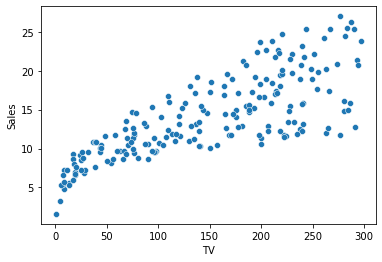

In [20]:
sns.scatterplot(x=dataset['TV'],
                y=dataset['Sales'])

In [21]:
#Import the class
from sklearn.tree import DecisionTreeRegressor

X=dataset[['TV']]
y=dataset['Sales']

#Create an object (model)
dtr1 = DecisionTreeRegressor(max_depth=2,
                             random_state=1)

#Fit (train) the model
dtr1.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=1)

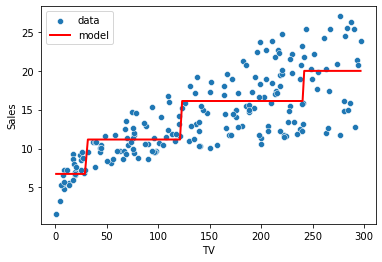

In [22]:
sns.scatterplot(x=dataset['TV'],
                y=dataset['Sales'],
                label='data')

plt.plot(dataset['TV'].sort_values(),       
         dtr1.predict(dataset['TV'].sort_values().to_frame()),
         color='red', label='model',
         linewidth=2)

plt.legend()

plt.savefig('model.png')

In [27]:
from sklearn.tree import export_graphviz

export_graphviz(dtr1, out_file='tree.dot', feature_names=['TV'])
#http://www.graphviz.org/ 
#open dot format in above link

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10,
                                                    random_state=0,
                                                    shuffle=True)

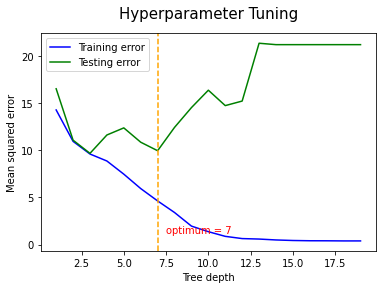

In [29]:
from sklearn.metrics import mean_squared_error as mse

max_depths = range(1, 20)
training_error = []
for max_depth in max_depths:
    model_1 = DecisionTreeRegressor(max_depth=max_depth)
    model_1.fit(X, y)
    training_error.append(mse(y, model_1.predict(X)))
    
testing_error = []
for max_depth in max_depths:
    model_2 = DecisionTreeRegressor(max_depth=max_depth)
    model_2.fit(X_train, y_train)
    testing_error.append(mse(y_test, model_2.predict(X_test)))

plt.plot(max_depths, training_error, color='blue', label='Training error')
plt.plot(max_depths, testing_error, color='green', label='Testing error')
plt.xlabel('Tree depth')
plt.axvline(x=7, color='orange', linestyle='--')
plt.annotate('optimum = 7', xy=(7.5, 1.17), color='red')
plt.ylabel('Mean squared error')
plt.title('Hyperparameter Tuning', pad=15, size=15)
plt.legend()

In [30]:
from sklearn.model_selection import GridSearchCV

model = DecisionTreeRegressor()

gs = GridSearchCV(model,
                  param_grid = {'max_depth': range(1, 11),
                                'min_samples_split': range(10, 60, 10)},
                  cv=5,
                  n_jobs=1,
                  scoring='neg_mean_squared_error')

gs.fit(X_train, y_train)

print(gs.best_params_)
print(-gs.best_score_)

{'max_depth': 3, 'min_samples_split': 30}
11.946222705843777


Text(0.5, 1.0, 'Best Fitting')

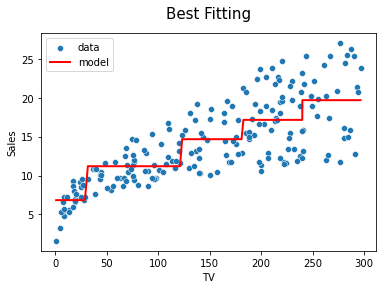

In [31]:
sns.scatterplot(x=dataset['TV'],
                y=dataset['Sales'],
                label='data')

new_model = DecisionTreeRegressor(max_depth=9,
                                  min_samples_split=50)
#or new_model = gs.best_estimator_
new_model.fit(X_train, y_train)

plt.plot(dataset['TV'].sort_values(),       
         new_model.predict(dataset['TV'].sort_values().to_frame()),
         color='red', label='model',
         linewidth=2)

plt.legend()
plt.title('Best Fitting', pad=15, size=15)